In [27]:
import pandas as pd
import seaborn as sns
import numpy as np
df = pd.read_csv("C:/Users/simpl/OneDrive/Documents/GitHub/tstat280/data/tacoma_houses.csv", low_memory=False, index_col=0)
df.head()

,Directions,Fireplace Y/N,Irrigation Water Rights Y/N,Inclusions,Basement,Bedrooms Possible,Window Features,Land Lease Y/N,Garage Y/N,Gulf-Front,...,Baths Three Quarter Lower,beds,Listing Terms,View Y/N,County,Lot Features,Number of Homes in Park,Assoc/CIC,Latitude,Longitude
Exterior Description,,,,,,,,,,,,,,,,,,,,,
NaN,NaN,No,No,NaN,NaN,2.0,NaN,No,Yes,NaN,...,0.0,2 Beds,NaN,No,Pierce,Paved,NaN,NaN,47.253662,-122.501020
NaN,WA-512 (East or West) to Steele St exit. Go So...,Yes,No,"Dishwashers, Dryers, GarbageDisposal, Microwav...",NaN,3.0,NaN,No,Yes,NaN,...,0.0,3 Beds,"Cash Out, Conventional, VA Loan",Yes,Pierce,"Curbs, Dead End Street, Paved, Sidewalk",NaN,NaN,47.135711,-122.447555
NaN,"South on Canyon Rd, West on 176th, South on 38...",Yes,Yes,"Dishwasher(s), Dryer(s), Garbage Disposal, Lea...",NaN,4.0,NaN,No,Yes,NaN,...,0.0,4 Beds,"Cash Out, Conventional, FHA, VA Loan",NaN,Pierce,"Curbs, Dead End Street, Paved, Sidewalk",NaN,NaN,47.091209,-122.381868
NaN,"Head west on SW 356th, which becomes 29th St. ...",Yes,No,"Dishwasher(s), Garbage Disposal, Refrigerator(...",Finished,NaN,NaN,No,Yes,NaN,...,0.0,3 Beds,"Cash Out, Conventional, FHA, VA Loan",NaN,Pierce,"Alley, Paved, Sidewalk",NaN,NaN,47.285087,-122.369776
NaN,"GPS friendly. Follow Pearl to 42nd, left on 4...",No,No,"Dishwasher(s), Dryer(s), Refrigerator(s), Stov...",NaN,3.0,NaN,No,Yes,NaN,...,0.0,3 Beds,NaN,NaN,Pierce,"Curbs, Paved, Sidewalk",NaN,NaN,47.286240,-122.517141


In [28]:
import math
df["house_number"] = df["address"].str.split().str[0]
#In complete transparancy, some of the following code is produced by AI in line with your regulations on AI usage on the project.
#I can verify what is happening, even for the sections that have not been covered in class with knowledge from prior experience and documemtation and I had Claude generate the code based off of my ideas and decisions
#This first chunk is also pulled from the data cleaning portion directly. Feel free to gloss over it.
# ─────────────────────────────────────────────────────────────
# 1. INCLUSIONS
# ─────────────────────────────────────────────────────────────
# Fill missing with "None"
df['Inclusions'] = df['Inclusions'].fillna('None')

# Canonical name map — normalise plurals, spacing, and slash variants
inclusion_name_map = {
    'dishwasher(s)': 'Dishwasher', 'dishwashers': 'Dishwasher', 'dishwasher': 'Dishwasher',
    'dryer(s)': 'Dryer', 'dryers': 'Dryer', 'dryer': 'Dryer',
    'washer(s)': 'Washer', 'washers': 'Washer', 'washer': 'Washer',
    'microwave(s)': 'Microwave', 'microwaves': 'Microwave', 'microwave': 'Microwave',
    'refrigerator(s)': 'Refrigerator', 'refrigerators': 'Refrigerator', 'refrigerator': 'Refrigerator',
    "stove(s)/range(s)": 'StoveRange', 'stovesranges': 'StoveRange', 'stoverange': 'StoveRange',
    'range/oven': 'StoveRange', 'rangeoven': 'StoveRange',
    'garbage disposal': 'GarbageDisposal', 'garbagedisposal': 'GarbageDisposal', 'garbage': 'GarbageDisposal',
    'double oven': 'DoubleOven', 'doubleoven': 'DoubleOven',
    'trash compactor': 'TrashCompactor', 'trashcompactor': 'TrashCompactor',
    'leased equipment': 'LeasedEquipment', 'leasedequipment': 'LeasedEquipment',
    'security system': 'SecuritySystem', 'securitysystem': 'SecuritySystem',
    'above ground pool': 'AboveGroundPool', 'abovegroundpool': 'AboveGroundPool',
    'awnings': 'Awnings',
    'drapes': 'Drapes',
    'cable/tv': 'CableTV',
    'sewer': 'Sewer',
    'water': 'Water',
    'see remarks': None, 'seeremarks': None, 'seeremarks_': None,
    'none': None,
}

def normalise_inclusions(value):
    if pd.isna(value) or value.strip().lower() == 'none':
        return 'None'
    canonical_items = []
    for raw in value.split(','):
        key = raw.strip().lower()
        canonical = inclusion_name_map.get(key)
        if canonical:
            canonical_items.append(canonical)
    return ', '.join(sorted(set(canonical_items))) if canonical_items else 'None'

df['Inclusions'] = df['Inclusions'].apply(normalise_inclusions)


# ─────────────────────────────────────────────────────────────
# 2. TOTAL BEDROOMS  (re-derive from upper + lower)
# ─────────────────────────────────────────────────────────────
df['Bedrooms Upper'] = df['Bedrooms Upper'].fillna(0)
df['Bedrooms Lower'] = df['Bedrooms Lower'].fillna(0)
df['Total Bedrooms'] = (df['Bedrooms Upper'] + df['Bedrooms Lower']).astype(int)
df.drop(columns=['Bedrooms Upper', 'Bedrooms Lower'], inplace=True)


# ─────────────────────────────────────────────────────────────
# 3. GARAGE Y/N
# ─────────────────────────────────────────────────────────────
# Where Garage Y/N is missing, use Attached Garage value; else "No"
df['Garage Y/N'] = df['Garage Y/N'].fillna(df['Attached Garage']).fillna('No')
df['Garage Y/N'] = df['Garage Y/N'].map({'Yes': 1, 'No': 0})
df.drop(columns=['Attached Garage'], inplace=True)


# ─────────────────────────────────────────────────────────────
# 4. AIR CONDITIONING Y/N  (1 missing row → delete)
# ─────────────────────────────────────────────────────────────
df.dropna(subset=['Air Conditioning Y/N'], inplace=True)
df['Air Conditioning Y/N'] = df['Air Conditioning Y/N'].map({'Yes': 1, 'No': 0})


# ─────────────────────────────────────────────────────────────
# 5. BATHROOMS  (1 missing row → delete)
# ─────────────────────────────────────────────────────────────
df.dropna(subset=['Bathrooms'], inplace=True)
# Already floats — no further conversion needed


# ─────────────────────────────────────────────────────────────
# 6. TOTAL PARKING  (fill with median rounded down → 2)
# ─────────────────────────────────────────────────────────────
parking_median_floor = math.floor(df['Total Parking'].median())
df['Total Parking'] = df['Total Parking'].fillna(parking_median_floor).astype(int)


# ─────────────────────────────────────────────────────────────
# 7. SITE FEATURES  (missing → "None"; standardise item names)
# ─────────────────────────────────────────────────────────────
df['Site Features'] = df['Site Features'].fillna('None')

def normalise_site_features(value):
    if pd.isna(value) or value.strip().lower() == 'none':
        return 'None'
    items = sorted(set(item.strip() for item in value.split(',') if item.strip()))
    return ', '.join(items)

df['Site Features'] = df['Site Features'].apply(normalise_site_features)


# ─────────────────────────────────────────────────────────────
# 8. INTERIOR FEATURES  (missing → "None"; fix truncations, standardise names)
# ─────────────────────────────────────────────────────────────
df['Interior Features'] = df['Interior Features'].fillna('None')

# Truncated / variant entries to fix before keeping as categories
interior_fix_map = {
    # Truncations
    'fi': None, 'fir': None, 'fire': None, 'firepl': None,
    'v': None, 'vaulted c': None, 'vaulted ce': None, 'vaulted ceili': None, 'vaulted ceiling': None,
    'w': None, 'wa': None, 'wal': None, 'walk': None, 'walk-': None, 'walk-i': None, 'walk-in': None,
    'walk-in clos': None, 'walk-in close': None, 'walk-in closet(s': None,
    'walk-in pa': None, 'walk-in pant': None, 'walk-in pantr': None,
    'wall': None, 'wall to': None, 'wall to wa': None, 'wall to wall c': None,
    'wall to wall ca': None, 'wall to wall car': None, 'wall to wall carp': None,
    'wat': None, 'water h': None, 'water he': None, 'water hea': None, 'water heat': None, 'water heate': None,
    'wi': None, 'wir': None, 'wire': None, 'wired f': None, 'wired for gener': None,
    's': None, 'high t': None, 'skyligh': None, 'solarium/atr': None,
    'spr': None, 'sprinkl': None, 'sprinkler': None,
    'security sy': None, 'wine cell': None,
    # Variants
    'fir/softwood': 'Fir/Softwood',
    'walk-in closet(s)': 'Walk-In Closet(s)',
    'walk-in pantry': 'Walk-In Pantry',
    'vaulted ceiling(s)': 'Vaulted Ceiling(s)',
    'wall to wall carpet': 'Wall to Wall Carpet',
    'water heater': 'Water Heater',
    'wired for generator': 'Wired for Generator',
    'skylight(s)': 'Skylight(s)',
    'solarium/atrium': 'Solarium/Atrium',
    'sprinkler system': 'Sprinkler System',
    'security system': 'Security System',
    'wine cellar': 'Wine Cellar',
    'high tech cabling': 'High Tech Cabling',
    'fireplace (primary bedroom)': 'Fireplace (Primary Bedroom)',
}

def normalise_interior_features(value):
    if pd.isna(value) or value.strip().lower() == 'none':
        return 'None'
    clean_items = []
    for raw in value.split(','):
        item = raw.strip()
        lower = item.lower()
        mapped = interior_fix_map.get(lower, item)  # None means truncated junk → skip
        if mapped:
            clean_items.append(mapped)
    return ', '.join(sorted(set(clean_items))) if clean_items else 'None'

df['Interior Features'] = df['Interior Features'].apply(normalise_interior_features)


# ─────────────────────────────────────────────────────────────
# 9. SECURITY FEATURES  (missing → "None"; standardise names)
# ─────────────────────────────────────────────────────────────
df['Security Features'] = df['Security Features'].fillna('None')

security_name_map = {
    'fullyfenced': 'Fully Fenced',
    'partiallyfenced': 'Partially Fenced',
    'securitysystem': 'Security System',
    'securitygate': 'Security Gate',
    'securityservice': 'Security Service',
    'securityservices': 'Security Service',
    'fully fenced': 'Fully Fenced',
    'partially fenced': 'Partially Fenced',
    'security system': 'Security System',
    'security gate': 'Security Gate',
    'security service': 'Security Service',
}

def normalise_security_features(value):
    if pd.isna(value) or value.strip().lower() == 'none':
        return 'None'
    clean_items = []
    for raw in value.split(','):
        key = raw.strip().lower().replace(' ', '')
        # Try both spaced and non-spaced lookups
        canonical = security_name_map.get(raw.strip().lower()) or security_name_map.get(key)
        if canonical:
            clean_items.append(canonical)
    return ', '.join(sorted(set(clean_items))) if clean_items else 'None'

df['Security Features'] = df['Security Features'].apply(normalise_security_features)


# ─────────────────────────────────────────────────────────────
# 10. HOUSE SIZE
# ─────────────────────────────────────────────────────────────
# Remove commas and "SQFT", convert to int
df['house_size'] = (
    df['house_size']
    .str.replace(',', '', regex=False)
    .str.replace('SQFT', '', regex=False)
    .str.strip()
    .astype(int)
)


# ─────────────────────────────────────────────────────────────
# 11. TAX ANNUAL AMOUNT  (fill with mean)
# ─────────────────────────────────────────────────────────────
df['Tax Annual Amount'] = (
    df['Tax Annual Amount']
    .str.replace(r'[\$,\s]', '', regex=True)
    .replace('', np.nan)
    .astype(float)
)
tax_mean = df['Tax Annual Amount'].mean()
df['Tax Annual Amount'] = df['Tax Annual Amount'].fillna(tax_mean)


# ─────────────────────────────────────────────────────────────
# 12. YEAR BUILT → HOUSE AGE
# ─────────────────────────────────────────────────────────────
df['House Age'] = 2026 - df['Year Built']
df.drop(columns=['Year Built'], inplace=True)


# ─────────────────────────────────────────────────────────────
# 13. MLS AREA  (keep numeric code only)
# ─────────────────────────────────────────────────────────────
df['MLS Area'] = df['MLS Area'].str.extract(r'^(\d+)').astype(int)


# ─────────────────────────────────────────────────────────────
# 14. LEVELS  (pull from Stories Count where missing, else mode; standardise to float)
# ─────────────────────────────────────────────────────────────
levels_std_map = {
    'One': 1.0, 'Two': 2.0, 'Three Or More': 3.0,
    'One and One Half': 1.5, 'OneAndOneHalf': 1.5,
    'Multi/Split': 2.0,
}

# Stories Count has only the value 2.0 in this dataset
stories_to_levels = {2.0: 2.0}

def fill_levels(row):
    val = row['Levels']
    if pd.isna(val):
        sc = row['Stories Count']
        if not pd.isna(sc):
            return stories_to_levels.get(sc, np.nan)
        return np.nan
    return levels_std_map.get(val, np.nan)

df['Levels'] = df.apply(fill_levels, axis=1)

# Fill remaining NaN with mode (1.0)
levels_mode = df['Levels'].mode()[0]
df['Levels'] = df['Levels'].fillna(levels_mode)
df.drop(columns=['Stories Count'], inplace=True)


# ─────────────────────────────────────────────────────────────
# 15. LOT SIZE  (remove "Acres", convert to float)
# ─────────────────────────────────────────────────────────────
# All values are already in Acres — strip the unit and convert
df['lot_size'] = (
    df['lot_size']
    .str.replace('Acres', '', regex=False)
    .str.strip()
    .astype(float)
)


# ─────────────────────────────────────────────────────────────
# 16. FLOORING  (fill Unknown; standardise names; keep as category string)
# ─────────────────────────────────────────────────────────────
df['Flooring'] = df['Flooring'].fillna('Unknown')

flooring_name_map = {
    'Engineered Hardwood': 'Hardwood',
    'Laminate Hardwood': 'Laminate',
    'Laminate Tile': 'Laminate',
    'Bamboo/Cork': 'Bamboo',
    'See Remarks': 'Unknown',
    'Other': 'Unknown',
}

def normalise_flooring(value):
    if pd.isna(value) or value.strip().lower() == 'unknown':
        return 'Unknown'
    clean_items = []
    for raw in value.split(','):
        item = raw.strip()
        item = flooring_name_map.get(item, item)
        clean_items.append(item)
    return ', '.join(sorted(set(clean_items))) if clean_items else 'Unknown'

df['Flooring'] = df['Flooring'].apply(normalise_flooring)


# ─────────────────────────────────────────────────────────────
# 17. HOA  (fill missing with "No"; convert to binary 0/1)
# ─────────────────────────────────────────────────────────────
def hoa_to_binary(val):
    if pd.isna(val):
        return 0
    s = str(val).strip().lower()
    if s in ('no', '0', ''):
        return 0
    if s == 'yes':
        return 1
    try:
        return 0 if float(s) == 0 else 1
    except ValueError:
        return 0

df['HOA'] = df['HOA'].apply(hoa_to_binary)


# ─────────────────────────────────────────────────────────────
# 18. HOA FEE  (fill 0; remove $ and whitespace; convert to float)
# ─────────────────────────────────────────────────────────────
df['HOA Fee'] = (
    df['HOA Fee']
    .fillna('$0')
    .str.replace(r'[\$,\s]', '', regex=True)
    .replace('', '0')
    .astype(float)
)


# ─────────────────────────────────────────────────────────────
# 19. PROPERTY CONDITION  (fill Unknown; standardise; map to ordinal)
# ─────────────────────────────────────────────────────────────
df['Property Condition'] = df['Property Condition'].fillna('Unknown')

property_condition_map = {
    'Fixer': 1,
    'Fair': 2,
    'Average': 3,
    'Resale': 3,
    'Good': 4,
    'Restored': 4,
    'Very Good': 5,
    'Remodeled': 5,
    'Updated/Remodeled': 5,
    'Under Construction': 5,
    'Unknown': 0,
}

df['Property Condition'] = df['Property Condition'].map(property_condition_map).fillna(0).astype(int)


# ─────────────────────────────────────────────────────────────
# 20. FOUNDATION DETAILS  (fill Unknown; standardise names; keep as category string)
# ─────────────────────────────────────────────────────────────
df['Foundation Details'] = df['Foundation Details'].fillna('Unknown')

foundation_name_map = {
    'Concrete Slab': 'Slab',
    'See Remarks': 'Unknown',
}

def normalise_foundation(value):
    if pd.isna(value) or value.strip().lower() == 'unknown':
        return 'Unknown'
    clean_items = []
    for raw in value.split(','):
        item = raw.strip()
        item = foundation_name_map.get(item, item)
        clean_items.append(item)
    return ', '.join(sorted(set(clean_items))) if clean_items else 'Unknown'

df['Foundation Details'] = df['Foundation Details'].apply(normalise_foundation)


# ─────────────────────────────────────────────────────────────
# 21. LOT FEATURES  (fill None; standardise names; keep as category string)
# ─────────────────────────────────────────────────────────────
df['Lot Features'] = df['Lot Features'].fillna('None')

lot_feature_name_map = {
    'Drought Res Landscape': 'Drought Resistant Landscape',
}

def normalise_lot_features(value):
    if pd.isna(value) or value.strip().lower() == 'none':
        return 'None'
    clean_items = []
    for raw in value.split(','):
        item = raw.strip()
        item = lot_feature_name_map.get(item, item)
        clean_items.append(item)
    return ', '.join(sorted(set(clean_items))) if clean_items else 'None'

df['Lot Features'] = df['Lot Features'].apply(normalise_lot_features)


# ─────────────────────────────────────────────────────────────
# FINAL: Keep only cleaned target columns
# ─────────────────────────────────────────────────────────────
final_cols = [
    'Total Bedrooms', 'Garage Y/N', 'Air Conditioning Y/N', 'Bathrooms',
    'Total Parking', 'Inclusions', 'Site Features', 'Interior Features',
    'Security Features', 'house_size', 'Tax Annual Amount', 'House Age',
    'MLS Area', 'Levels', 'lot_size', 'Flooring', 'HOA', 'HOA Fee',
    'Property Condition', 'Foundation Details', 'Lot Features',
]

df["Close Price"] = (
    df["Close Price"].str.replace("$", "")
    .str.replace(",", "")
    .astype("int")
)
df["price"] = (
    df["price"].str.replace("$", "")
    .str.replace(",", "")
    .astype("int")
)


df["log_price"] = np.log(df["price"] +1)

df["log_Close Price"] = np.log(df["Close Price"] +1)


In [29]:
df.head()

,Directions,Fireplace Y/N,Irrigation Water Rights Y/N,Inclusions,Basement,Bedrooms Possible,Window Features,Land Lease Y/N,Garage Y/N,Gulf-Front,...,County,Lot Features,Number of Homes in Park,Assoc/CIC,Latitude,Longitude,house_number,House Age,log_price,log_Close Price
Exterior Description,,,,,,,,,,,,,,,,,,,,,
NaN,NaN,No,No,None,NaN,2.0,NaN,No,1,NaN,...,Pierce,Paved,NaN,NaN,47.253662,-122.501020,722,76,12.542548,12.542548
NaN,WA-512 (East or West) to Steele St exit. Go So...,Yes,No,"Dishwasher, Dryer, GarbageDisposal, Microwave,...",NaN,3.0,NaN,No,1,NaN,...,Pierce,"Curbs, Dead End Street, Paved, Sidewalk",NaN,NaN,47.135711,-122.447555,13322,8,13.180634,13.180634
NaN,"South on Canyon Rd, West on 176th, South on 38...",Yes,Yes,"Dishwasher, Dryer, GarbageDisposal, LeasedEqui...",NaN,4.0,NaN,No,1,NaN,...,Pierce,"Curbs, Dead End Street, Paved, Sidewalk",NaN,NaN,47.091209,-122.381868,18201,1,13.280991,13.280991
NaN,"Head west on SW 356th, which becomes 29th St. ...",Yes,No,"Dishwasher, GarbageDisposal, Refrigerator, Sto...",Finished,NaN,NaN,No,1,NaN,...,Pierce,"Alley, Paved, Sidewalk",NaN,NaN,47.285087,-122.369776,3111,37,13.180634,13.180634
NaN,"GPS friendly. Follow Pearl to 42nd, left on 4...",No,No,"Dishwasher, Dryer, Refrigerator, StoveRange, W...",NaN,3.0,NaN,No,1,NaN,...,Pierce,"Curbs, Paved, Sidewalk",NaN,NaN,47.286240,-122.517141,6010,44,13.071072,13.071072


(Part 1)
Create a visualization of the response variable. Determine if any transformation should be applied to the response to make the data look more "normal".

<Axes: xlabel='price', ylabel='Count'>

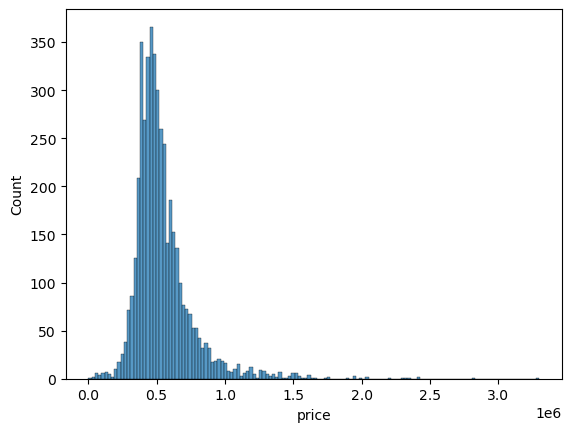

In [30]:
sns.histplot(df["price"])
# Distribution of price

<Axes: xlabel='log_price', ylabel='Count'>

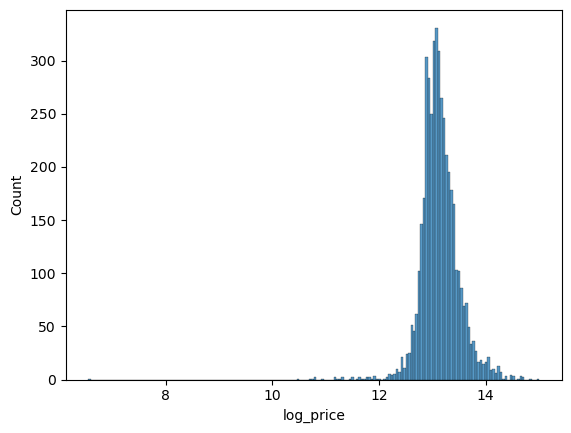

In [31]:
df["log_price"] = np.log(df["price"])

sns.histplot(df["log_price"])
# Distribution of log price

<Axes: xlabel='house_size', ylabel='Count'>

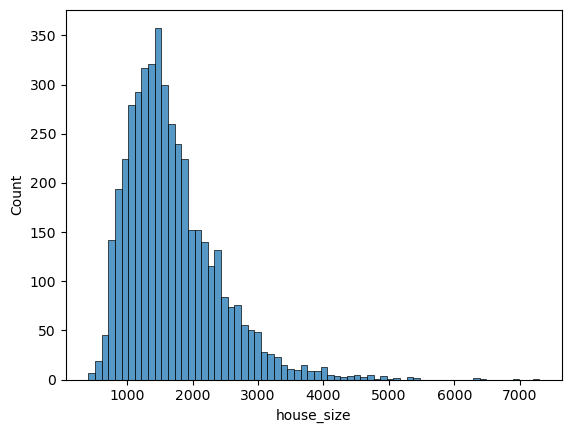

In [32]:
sns.histplot(df["house_size"])
# Distribution of square footage of houses

<Axes: xlabel='Total Bedrooms', ylabel='count'>

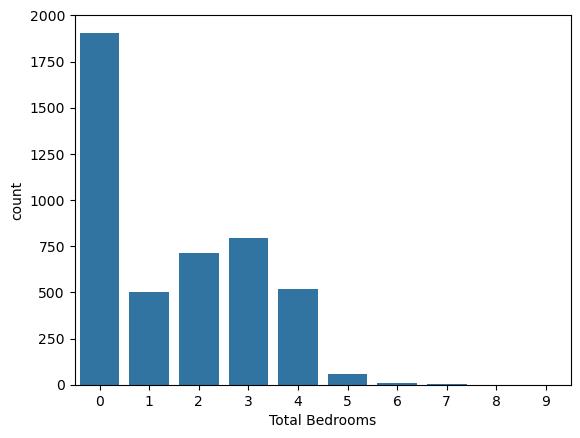

In [33]:
sns.countplot(data=df, x="Total Bedrooms")
# Distribution of bedrooms

<Axes: xlabel='Bathrooms', ylabel='Count'>

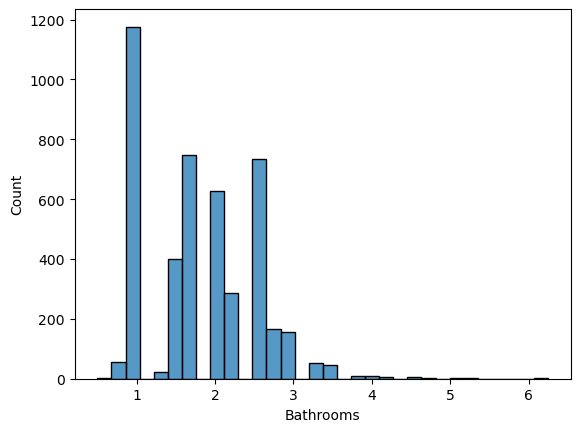

In [34]:
sns.histplot(df["Bathrooms"])
# Distribution of bathrooms

<Axes: xlabel='lot_size', ylabel='Count'>

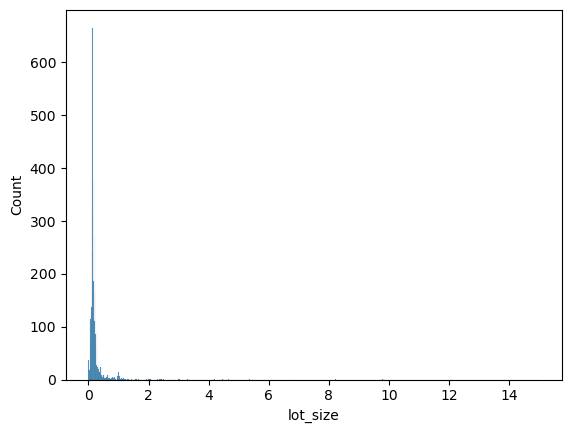

In [35]:
sns.histplot(df["lot_size"])
# Distribution of lot/yard sizes in sq ft

(Part 2)

In [36]:
final_cols = [
    'Total Bedrooms', 'Garage Y/N', 'Air Conditioning Y/N', 'Bathrooms',
    'Total Parking', 'Inclusions', 'Site Features', 'Interior Features',
    'Security Features', 'house_size', 'Tax Annual Amount', 'House Age',
    'MLS Area', 'Levels', 'lot_size', 'Flooring', 'HOA', 'HOA Fee',
    'Property Condition', 'Foundation Details', 'Lot Features', 'price'
]

1) HOA can be condensed down to solely the HOA fee column.

2) The variable with the highest correlation are house size, bathrooms, and bedrooms.

4. These same variables listed above could indicate the amount of people a house could hold.

<Axes: xlabel='Bathrooms', ylabel='price'>

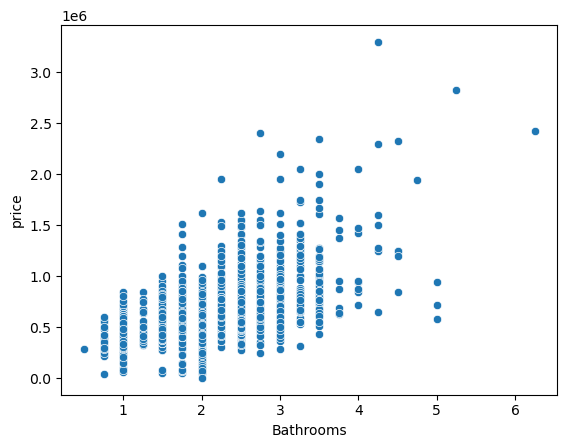

In [37]:
sns.scatterplot(
    data=df,
    x="Bathrooms",
    y="price"
)
# Compares price to number of bathrooms

<Axes: xlabel='house_size', ylabel='price'>

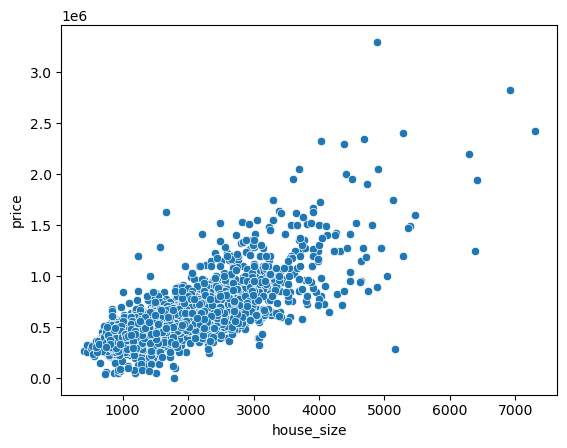

In [38]:
sns.scatterplot(
    data=df,
    x="house_size",
    y="price"
)
# Compares price to sq ft size of house

<Axes: xlabel='lot_size', ylabel='price'>

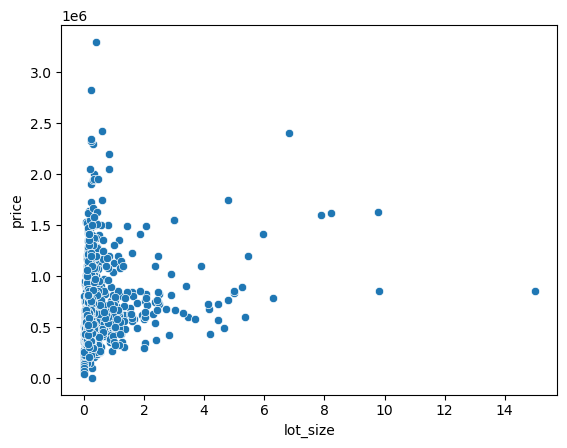

In [39]:
sns.scatterplot(
    data=df,
    x="lot_size",
    y="price"
)
# Compares price to the size of the lot/yard in sq ft

<Axes: xlabel='Total Bedrooms', ylabel='price'>

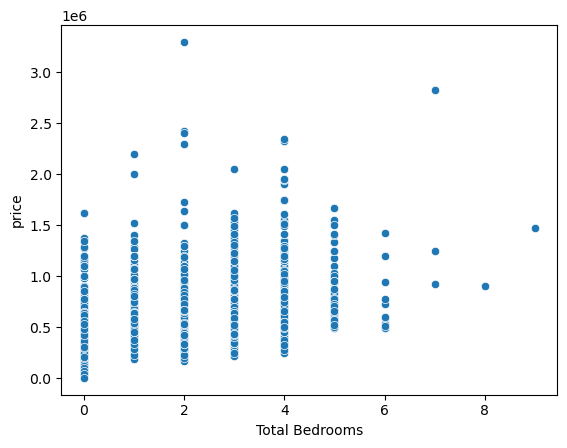

In [40]:
sns.scatterplot(
    data=df,
    x="Total Bedrooms",
    y="price"
)
# Compares price to number of bedrooms

3) We should change lot-size with a log transformation.

(Part 3)
Age of house could be a good feature to look at.

<Axes: xlabel='House Age', ylabel='price'>

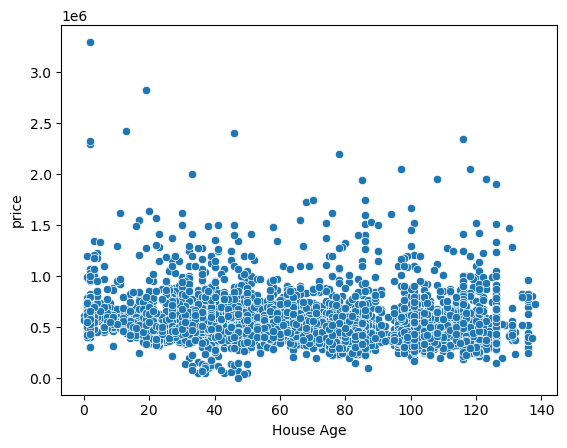

In [41]:
sns.scatterplot(
    data=df,
    x="House Age",
    y="price"
)
# Compares price to age of the house

There surprisingly doesn't show much of a linear correlation.

## Part 3 - Modeling starts here

Initial errors: price was still a string object and not a float or an integer

For this section of the project, you will now get practice fitting regression models using the housing dataset to try to predict house prices.

Model Fitting
Using your cleaned up dataset, fit a model to predict house price using the list of predictors you previously selected. Then do the following:

Make note of any errors you ran into when trying to fit the model for the first time.
Address these errors so that you can fit the model successfully.
Once the model has been fit successfully, take note of the RMSE and R2 for this model.
Model Evaluation and Checking
Do the following:

Compute the residuals for the model and create a plot of residuals on the y-axis vs fitted (predicted) values on the x-axis. Comment on whether there appear to be any violations of linearity.
Identify observations for which the model predicted poorly (i.e., they have large residuals). Determine if there appear to be any general patterns with houses for which the model is producing poor predictions. Can you think of anything that might help to address these issues?
Model Interpretation
Do the following:

Choose one quantitative variable in your model and interpret the coefficient for this variable in context.
Choose one categorical variable in your model and interpret one of the coefficients for this categorical variable in context.
Updating the Model
Finally, comment on anything that you might do to try to improve the model fit. Are there other predictors you would like to include? Are there other features you feel might be useful for improving the model?

You do not have to make the changes for this part of the project, but these ideas may be incorporated into the final version of the project.

In [42]:
df["price"] = (
    df["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

In [43]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer([
    ("num",
     SimpleImputer(strategy="median")),

    ("cat",
     Pipeline([
         ("imputer", SimpleImputer(strategy="most_frequent")),
         ("encoder", OneHotEncoder(handle_unknown="ignore"))
     ]))
])

In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

numeric_features = [
    'Total Bedrooms', 'Bathrooms', 'Total Parking',
    'house_size', 'Tax Annual Amount', 'House Age',
    'lot_size', 'HOA Fee', 'Garage Y/N', 'Air Conditioning Y/N',
    'MLS Area', 'Levels', 'HOA', 'Property Condition'
]

categorical_features = [
    'Inclusions', 'Site Features', 'Interior Features',
    'Security Features', 'Flooring', 'Foundation Details', 'Lot Features'
]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regression", LinearRegression())
])

all_features = [*numeric_features, *categorical_features]

# Drop rows where ALL numeric features are missing
df_clean = df.dropna(subset=numeric_features, how='all')
print(f"Rows before: {len(df)}, Rows after: {len(df_clean)}")

X = df_clean[all_features]
y = df_clean[['price']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)

Rows before: 4508, Rows after: 4508


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Total Bedrooms',
                                                   'Bathrooms', 'Total Parking',
                                                   'house_size',
                                                   'Tax Annual Amount',
                                                   'House Age', 'lot_size',
                                                   'HOA Fee', 'Garage Y/N',
                                                   'Air Conditioning Y/N',
                                                   'MLS Area', 'Levels', 'HOA',
                                                   'Property Condition']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Inclusions',
                                                   'Site Features',
                                                   'Interior Features',
                                                   'Security Features',
                                                   'Flooring',
                                                   'Foundation Details',
                                                   'Lot Features'])])),
                ('regression', LinearRegression())])

In [45]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

numeric_features = [
    'Total Bedrooms', 'Bathrooms', 'Total Parking',
    'house_size', 'Tax Annual Amount', 'House Age',
    'lot_size', 'HOA Fee', 'Garage Y/N', 'Air Conditioning Y/N',
    'MLS Area', 'Levels', 'HOA', 'Property Condition'
]

categorical_features = [
    'Inclusions', 'Site Features', 'Interior Features',
    'Security Features', 'Flooring', 'Foundation Details', 'Lot Features'
]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regression", LinearRegression())
])

all_features = [*numeric_features, *categorical_features]
df_clean = df.dropna(subset=numeric_features, how='all')

X = df_clean[all_features]
y = df_clean[['price']]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("RMSE:", rmse)
print("R²:", r2)

RMSE: 171974.26624611788
R²: 0.46212910720445166


In [47]:
# We were able to use the 21 variables we initially used
# The RMSE and R^2 seem to be within the range that would be considered "good" according to everyone else's RMSE and R^2 for this dataset.
# The features included were features that Ana and I thought were important.
# The last section was mostly used to debug errors that were getting thrown everytime, it was really annoying but it works now so hopefully that looks okay.
# Overall, this model seems okay and as long as it runs is what I say.

In [56]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import joblib

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train and save model
model = LinearRegression()
model.fit(X_scaled, y)
joblib.dump(model, "model.pkl")

['model.pkl']

In [53]:
# During training — save the list of column names
columns = X.columns.tolist()
joblib.dump(columns, "columns.pkl")

['columns.pkl']

In [55]:
# During training
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
joblib.dump(scaler, "scaler.pkl")

# In the app
scaler = joblib.load("scaler.pkl")